## Generate figure for drug x manuscript

## Import libraries

In [1]:
invisible(lapply(
    c("dplyr", "ggplot2", "grid", "patchwork", "RColorBrewer", "ggExtra", "ggridges", "ggplotify"),
    function(pkg) suppressPackageStartupMessages(suppressWarnings(library(pkg, character.only = TRUE)))
))


## Set paths

In [2]:
figure_dir <- "./figures"
output_main_figure <- file.path(figure_dir, "main_figure.png")


## Load in workflow image

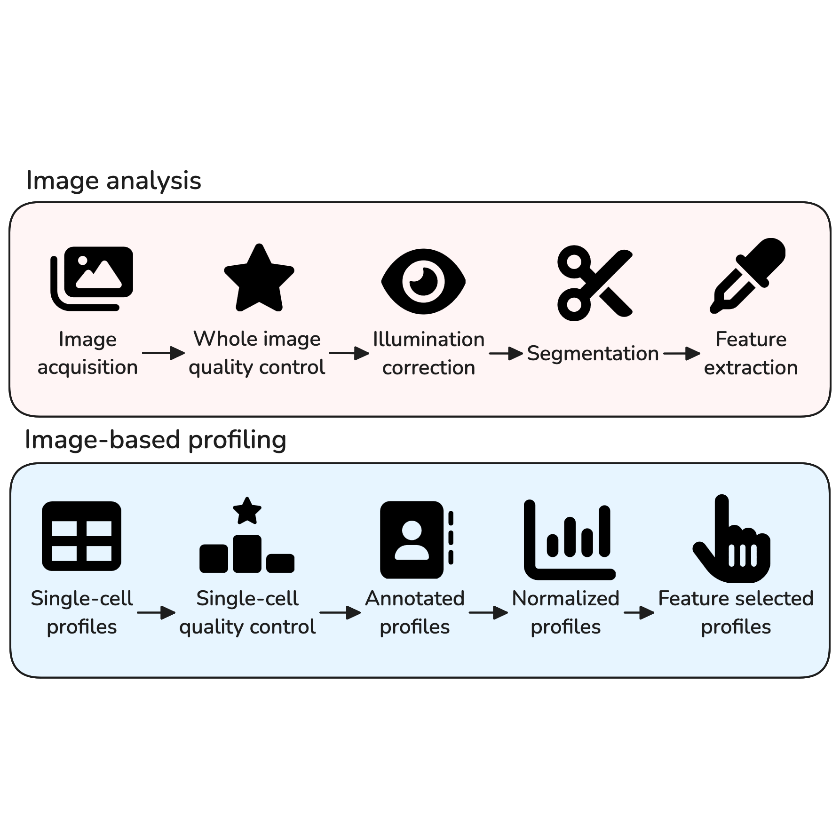

In [3]:
workflow_path <- file.path("figures/CFReT_workflow.png")
workflow_img <- png::readPNG(workflow_path)

# Get the dimensions of the image
img_height <- nrow(workflow_img)
img_width <- ncol(workflow_img)

# Calculate the aspect ratio
aspect_ratio <- img_height / img_width

# Plot the workflow image from BioRender to a ggplot object
workflow <- ggplot() +
    annotation_custom(
        rasterGrob(workflow_img, interpolate = TRUE),
        xmin = -Inf, xmax = Inf, ymin = -Inf, ymax = Inf
    ) +
    theme_void() +
    coord_fixed(ratio = aspect_ratio, clip = "off") +
    theme(plot.margin = margin(0, 0, 0, 0, "cm")) # Adjust margins as needed

workflow


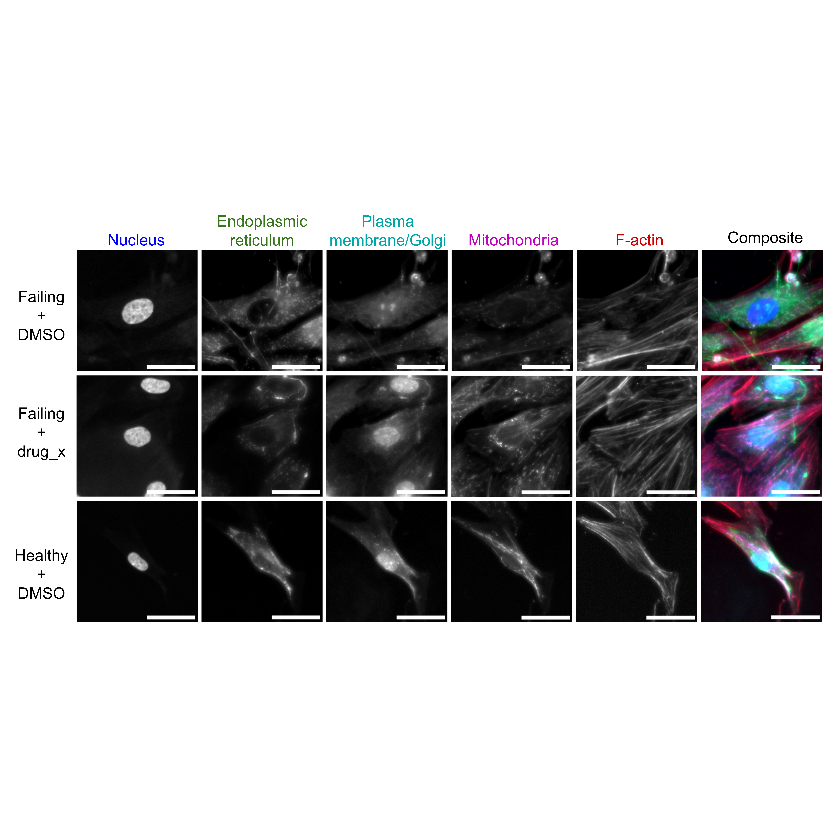

In [4]:
montage_path <- file.path("figures/example_montage.png")
montage_img <- png::readPNG(montage_path)

# Get the dimensions of the image
img_height <- nrow(montage_img)
img_width <- ncol(montage_img)

# Calculate the aspect ratio
aspect_ratio <- img_height / img_width

# Plot the montage image from BioRender to a ggplot object
montage <- ggplot() +
    annotation_custom(
        rasterGrob(montage_img, interpolate = TRUE),
        xmin = -Inf, xmax = Inf, ymin = -Inf, ymax = Inf
    ) +
    theme_void() +
    coord_fixed(ratio = aspect_ratio, clip = "off") +
    theme(plot.margin = margin(0, 0, 0, 0, "cm")) # Adjust margins as needed

montage


## Generate UMAP

In [5]:
# Path to UMAP results
UMAP_results_dir <- file.path(
    "../4.analyze_data/notebooks/UMAP/results"
)

# Load data
UMAP_results_file <- file.path(UMAP_results_dir, "UMAP_localhost230405150001_DMSO_drugx.parquet")

UMAP_results_df <- arrow::read_parquet(UMAP_results_file)

dim(UMAP_results_df)
head(UMAP_results_df)


[1] 15591    21

Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,⋯,Metadata_ImageNumber,Metadata_Plate,Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Metadata_Site,UMAP0,UMAP1
<chr>,<int>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<chr>,<dbl>,<dbl>
B,2,9,failing,rejected,DMSO,221.0468,137.1155,246.6028,109.2858,⋯,1,localhost230405150001,B02,1,1,6,6,f00,2.4665723,1.8230535
B,2,9,failing,rejected,DMSO,690.5961,183.0678,716.1701,177.1322,⋯,1,localhost230405150001,B02,2,2,7,7,f00,0.9708436,-1.5763690
B,2,9,failing,rejected,DMSO,626.5615,206.9237,623.9437,199.9064,⋯,1,localhost230405150001,B02,3,3,8,8,f00,-1.1790897,-0.3499455
B,2,9,failing,rejected,DMSO,559.4486,220.6882,528.6466,196.9556,⋯,1,localhost230405150001,B02,4,4,9,9,f00,1.4865675,1.0995189
B,2,9,failing,rejected,DMSO,909.0199,247.6943,897.9660,253.6218,⋯,1,localhost230405150001,B02,5,5,10,10,f00,2.2596562,2.2150373
B,2,9,failing,rejected,DMSO,330.7563,260.8621,341.5217,269.5020,⋯,1,localhost230405150001,B02,6,6,11,11,f00,2.9030669,2.8513165


Warning message:
“Removed 2048 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 2048 rows containing missing values or values outside the scale range
(`geom_line()`).”


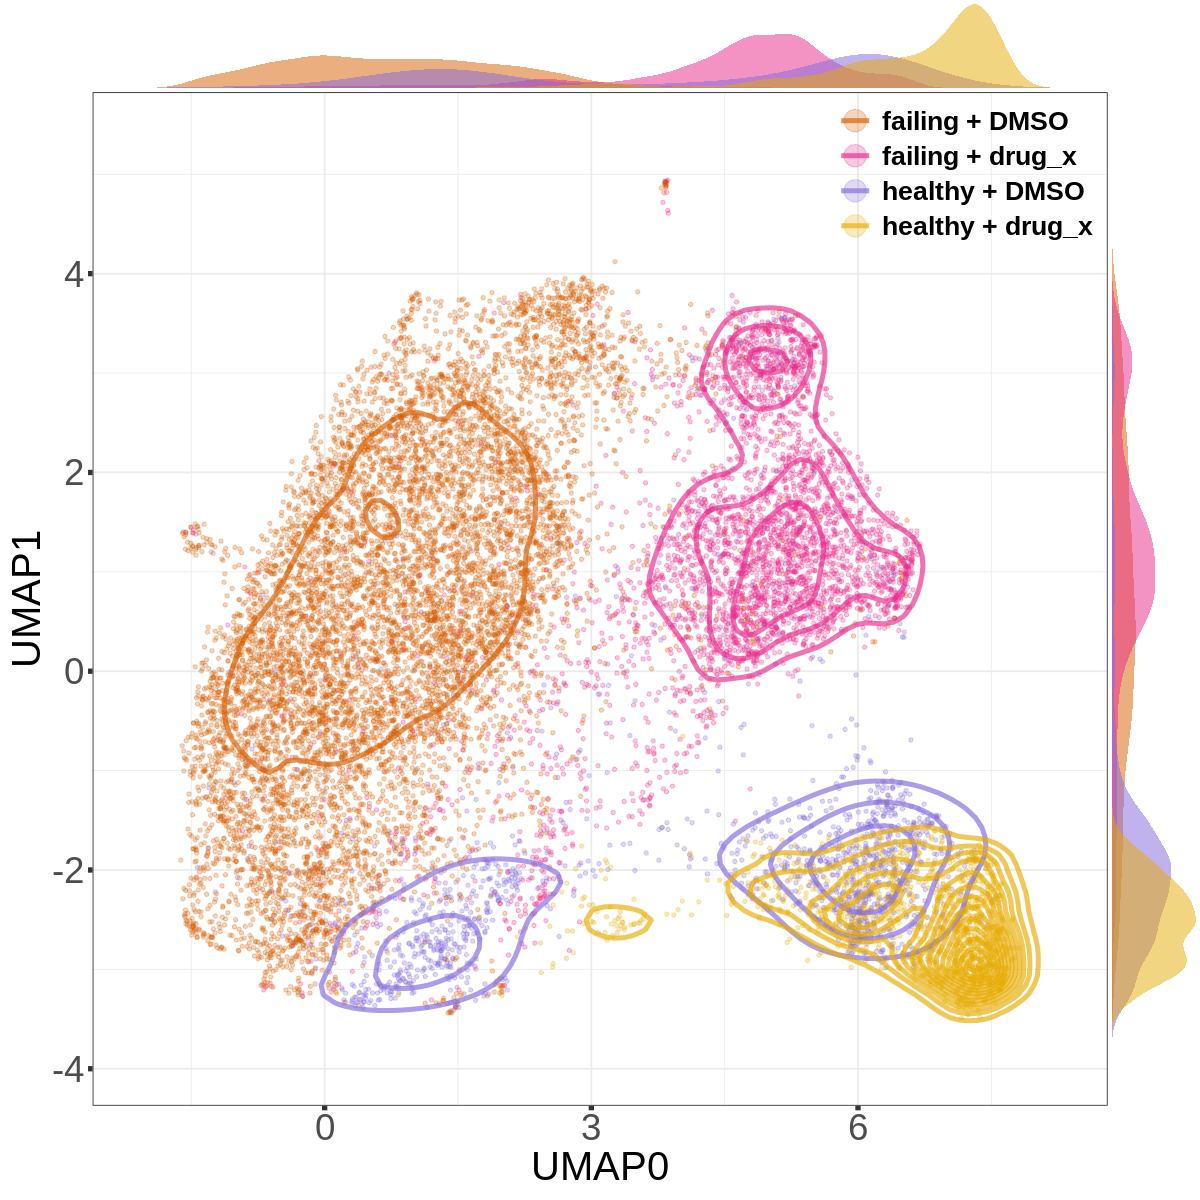

In [16]:
width <- 10
height <- 10
options(repr.plot.width = width, repr.plot.height = height)

# Create a new column combining cell type and treatment
UMAP_results_df <- UMAP_results_df %>%
    dplyr::mutate(Group = paste(Metadata_cell_type, Metadata_treatment, sep = " + "))

# Store the main UMAP plot as a ggplot object
umap_drugx_gg <- ggplot(UMAP_results_df, aes(x = UMAP0, y = UMAP1)) +
    geom_point(aes(color = Group), size = 0.9, alpha = 0.25) +
    geom_density_2d(aes(color = Group), alpha = 0.65, linewidth = 1.42) +
    theme_bw() +
    theme(
        strip.background = element_rect(color = "black", fill = "#fdfff4"),
        legend.position = c(0.11, 0.91),
        legend.background = element_blank(),
        legend.key = element_blank(),
        legend.title = element_blank(),
        legend.text = element_text(face = "bold"),
    ) +
    scale_color_manual(
        values = c("failing + drug_x" = "#E7298A", "failing + DMSO" = "#D55E00", "healthy + DMSO" = "#8269dc", "healthy + drug_x" = "#E6AB02"),
    ) +
    guides(color = guide_legend(override.aes = list(size = 6))) +
    # Increase the size of the axes by 5%
    ylim(range(UMAP_results_df$UMAP1) + c(-1, 1) * 0.05 * diff(range(UMAP_results_df$UMAP1))) +
    xlim(range(UMAP_results_df$UMAP0) + c(-1, 1) * 0.05 * diff(range(UMAP_results_df$UMAP0))) +
    theme(
        legend.position.inside = c(0.86, 0.92),
        legend.background = element_blank(),
        legend.key = element_blank(),
        legend.title = element_blank(),
        legend.text = element_text(size = 16),
        panel.background = element_rect(fill = "white"),
        plot.background = element_blank(),
        axis.text = element_text(size = 22),
        axis.title = element_text(size = 24),
        axis.ticks = element_line(linewidth = 1.5)
    )

# Add density plots in the margins
merged_drugx_plot_with_margins <- ggMarginal(
    umap_drugx_gg,
    type = "density",
    margins = "both",
    groupFill = TRUE,
    linewidth = 5,
    colour = NA,
    size = 11,
)

# update to ggplot object
ggplot_drugx_plot_with_margins <- as.ggplot(merged_drugx_plot_with_margins)

# Save figure
ggsave("./figures/panel_c_umap.pdf", merged_drugx_plot_with_margins, height = height, width = width, dpi = 500)

# print plot
print(ggplot_drugx_plot_with_margins)


## Probability proportion bar charts

In [7]:
# Path to probability results
prob_results_dir <- file.path(
    "../5.machine_learning/3.assess_generalizability/prob_data"
)

# Load data
prob_results_file <- file.path(prob_results_dir, "proportion_healthy_plate3_grouped.csv")

prob_results_df <- readr::read_csv(prob_results_file)

# Remove TGFRi treatment and rename hearts to match manuscript
prob_results_df <- prob_results_df |>
    dplyr::filter(Metadata_treatment != "TGFRi") |>
    dplyr::mutate(
        Metadata_heart_number = dplyr::case_when(
            Metadata_heart_number == 9 ~ "F5",
            Metadata_heart_number == 11 ~ "NF2",
            TRUE ~ as.character(Metadata_heart_number)
        )
    )

dim(prob_results_df)
head(prob_results_df)


Rows: 6 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): Metadata_treatment
dbl (2): Metadata_heart_number, proportion_healthy

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 4 3

Metadata_heart_number,Metadata_treatment,proportion_healthy
<chr>,<chr>,<dbl>
F5,DMSO,0.5313081
F5,drug_x,0.8213992
NF2,DMSO,1.0000000
NF2,drug_x,1.0000000


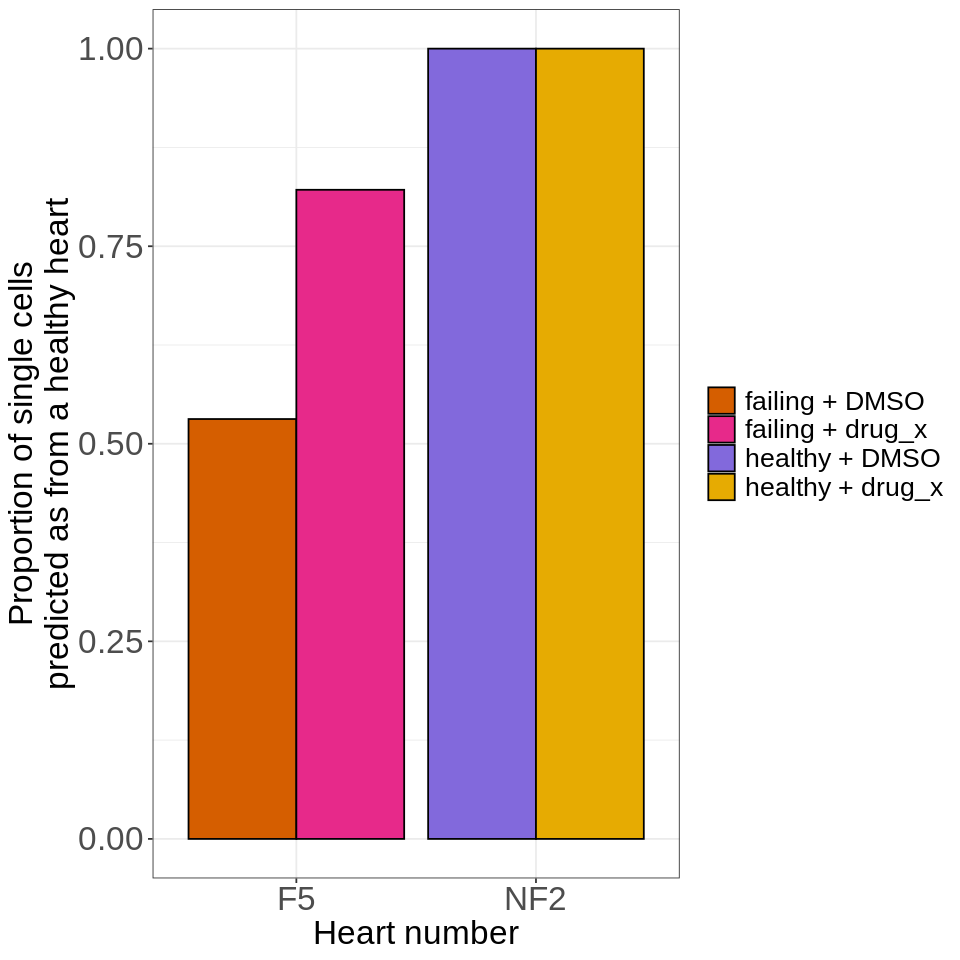

In [8]:
prob_results_df <- prob_results_df |>
    dplyr::mutate(bar_group = dplyr::case_when(
        Metadata_heart_number == "F5" & Metadata_treatment == "drug_x" ~ "failing + drug_x",
        Metadata_heart_number == "F5" & Metadata_treatment == "DMSO" ~ "failing + DMSO",
        Metadata_heart_number == "NF2" & Metadata_treatment == "DMSO" ~ "healthy + DMSO",
        Metadata_heart_number == "NF2" & Metadata_treatment == "drug_x" ~ "healthy + drug_x"
    ))

width <- 8
height <- 8
options(repr.plot.width = width, repr.plot.height = height)

# Create a bar plot
bar_plot <- ggplot(prob_results_df, aes(x = Metadata_heart_number, y = proportion_healthy, fill = bar_group)) +
    geom_bar(stat = "identity", position = position_dodge(), color = "black") +
    theme_bw() +
    labs(
        x = "Heart number",
        y = "Proportion of single cells\npredicted as from a healthy heart"
    ) +
    theme(
        axis.text.x = element_text(size = 20),
        axis.text.y = element_text(size = 20),
        axis.title.x = element_text(size = 20),
        axis.title.y = element_text(size = 20),
        legend.position = "right",
        legend.text = element_text(size = 16),
    ) +
    scale_fill_manual(
        name = NULL,
        values = c(
            "failing + drug_x" = "#E7298A",
            "failing + DMSO" = "#D55E00",
            "healthy + DMSO" = "#8269dc",
            "healthy + drug_x" = "#E6AB02"
        )
    )

# Save figure
ggsave("./figures/panel_d_bar_plot_proportion.pdf", bar_plot, height = height, width = width, dpi = 500)

# Print the plot
bar_plot


## Ridge plot of the pilot plates with dose curve

In [9]:
# Path to probability results for pilot data (plates 1 and 2)
pilot_results_dir <- file.path(
  "../5.machine_learning/3.assess_generalizability/prob_data"
)

# Load data
pilot_results_file <- file.path(pilot_results_dir, "combined_plates_1_2_predicted_proba.csv")

pilot_results_df <- readr::read_csv(pilot_results_file)

# Update the heart numbers to match manuscript
pilot_results_df <- pilot_results_df %>%
  mutate(Metadata_heart_number = recode(Metadata_heart_number, `3` = "F2", `8` = "F4", `9` = "F5")) %>%
  filter(!Metadata_heart_number %in% c("F4", "F5"))

# Add "uM" to all values in the Metadata_dose column
pilot_results_df$Metadata_dose <- paste0(as.character(pilot_results_df$Metadata_dose), "\nuM")

# Specify the levels in the desired order
dose_levels <- c("0\nuM", "0.005\nuM", "0.014\nuM", "0.04\nuM", "0.12\nuM", "0.37\nuM", "1.11\nuM", "3.33\nuM", "5\nuM", "10\nuM")

# Convert Metadata_dose to factor with specified levels
pilot_results_df$Metadata_dose <- factor(pilot_results_df$Metadata_dose, levels = dose_levels)

dim(pilot_results_df)
head(pilot_results_df)


Rows: 81290 Columns: 23
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (8): predicted_label, Metadata_WellRow, Metadata_treatment, Metadata_do...
dbl (15): Failing_probas, Healthy_probas, Metadata_WellCol, Metadata_heart_n...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 31472    23

Failing_probas,Healthy_probas,predicted_label,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_treatment,Metadata_dose,Metadata_dose_unit,Metadata_Nuclei_Location_Center_X,⋯,Metadata_Image_Count_Cells,Metadata_ImageNumber,Metadata_Plate,Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Metadata_Site,model_type
<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<fct>,<chr>,<dbl>,⋯,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2.078662e-03,0.9979213,Healthy,A,1,F2,drug_x,5 uM,uM,220.49110,⋯,35,1,localhost220512140003_KK22-05-198,A01,2,2,4,4,f00,final
3.521356e-03,0.9964786,Healthy,A,1,F2,drug_x,5 uM,uM,77.76578,⋯,35,1,localhost220512140003_KK22-05-198,A01,3,3,6,6,f00,final
3.725529e-03,0.9962745,Healthy,A,1,F2,drug_x,5 uM,uM,180.30225,⋯,35,1,localhost220512140003_KK22-05-198,A01,4,4,7,7,f00,final
3.266199e-05,0.9999673,Healthy,A,1,F2,drug_x,5 uM,uM,419.32820,⋯,35,1,localhost220512140003_KK22-05-198,A01,5,5,8,8,f00,final
2.070417e-03,0.9979296,Healthy,A,1,F2,drug_x,5 uM,uM,765.91288,⋯,35,1,localhost220512140003_KK22-05-198,A01,6,6,9,9,f00,final
1.324292e-03,0.9986757,Healthy,A,1,F2,drug_x,5 uM,uM,377.83268,⋯,35,1,localhost220512140003_KK22-05-198,A01,7,7,10,10,f00,final


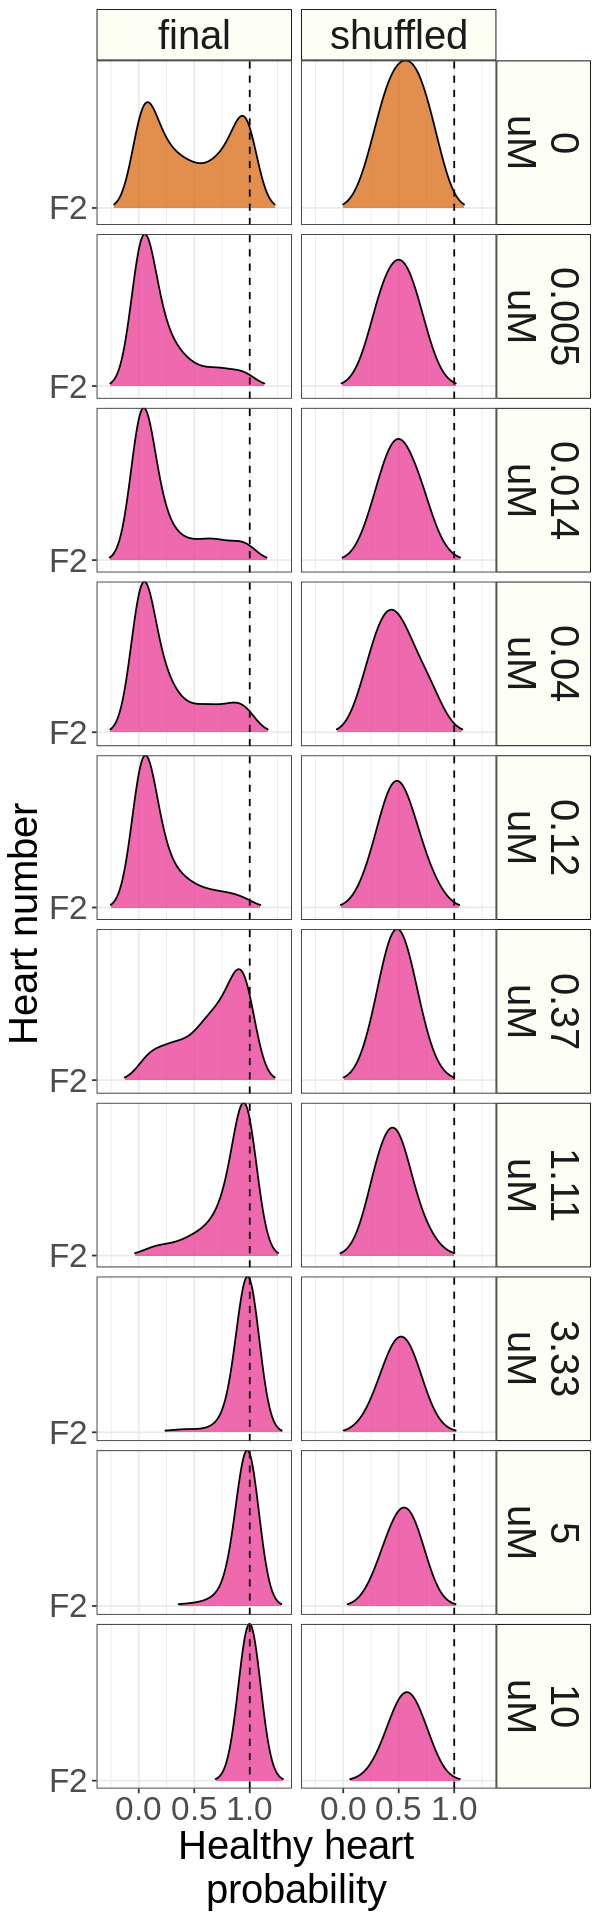

In [10]:
height <- 16
width <- 5
options(repr.plot.width = width, repr.plot.height = height)

# Define colors for the doses
zero_dose_color <- "#D55E00" # Unique color for 0 uM
all_other_doses_color <- "#E7298A" # Same color for all other doses
dose_colors <- c(
    "0\nuM" = zero_dose_color,
    "0.005\nuM" = all_other_doses_color,
    "0.014\nuM" = all_other_doses_color,
    "0.04\nuM" = all_other_doses_color,
    "0.12\nuM" = all_other_doses_color,
    "0.37\nuM" = all_other_doses_color,
    "1.11\nuM" = all_other_doses_color,
    "3.33\nuM" = all_other_doses_color,
    "5\nuM" = all_other_doses_color,
    "10\nuM" = all_other_doses_color
)

# Basic plot with custom colors
ridge_plot_healthy <- ggplot(pilot_results_df, aes(
    x = Healthy_probas,
    y = Metadata_heart_number,
    fill = Metadata_dose
)) +
    geom_density_ridges(alpha = 0.7, scale = 3, rel_min_height = 0.01, bandwidth = 0.1) +
    scale_fill_manual(values = dose_colors) +
    geom_vline(xintercept = 1, linetype = "dashed", color = "black") +
    scale_x_continuous(breaks = seq(0, 1, 0.5)) +
    facet_grid(Metadata_dose ~ model_type, scales = "free_y") +
    labs(
        y = "Heart number",
        x = "Healthy heart\nprobability",
    ) +
    theme_bw() +
    theme(
        legend.position = "none",
        axis.text = element_text(size = 20),
        axis.text.x = element_text(size = 20),
        axis.title = element_text(size = 24),
        strip.text = element_text(size = 24),
        strip.background = element_rect(
            colour = "black",
            fill = "#fdfff4"
        )
    )

# Save figure
ggsave("./figures/panel_e_ridge_plot.pdf", ridge_plot_healthy, height = height, width = width, dpi = 500)

# Show plot
ridge_plot_healthy


## Generate first panels

In [11]:
width <- 12
height <- 12
options(repr.plot.width = width, repr.plot.height = height)

panels_a_b_gg <- (
    workflow +
        montage
) + plot_layout(heights = c(1, 1))


## Generate second panels

In [12]:
width <- 12
height <- 12
options(repr.plot.width = width, repr.plot.height = height)

panels_c_d_gg <- (
    ggplot_drugx_plot_with_margins +
        free(bar_plot)
) + plot_layout(heights = c(1.2, 1))


In [13]:
width <- 26
height <- 16
options(repr.plot.width = width, repr.plot.height = height)

panels_a_b_c_d_gg <- (
    panels_a_b_gg |
        free(panels_c_d_gg)
) + plot_layout(widths = c(1.5, 1))


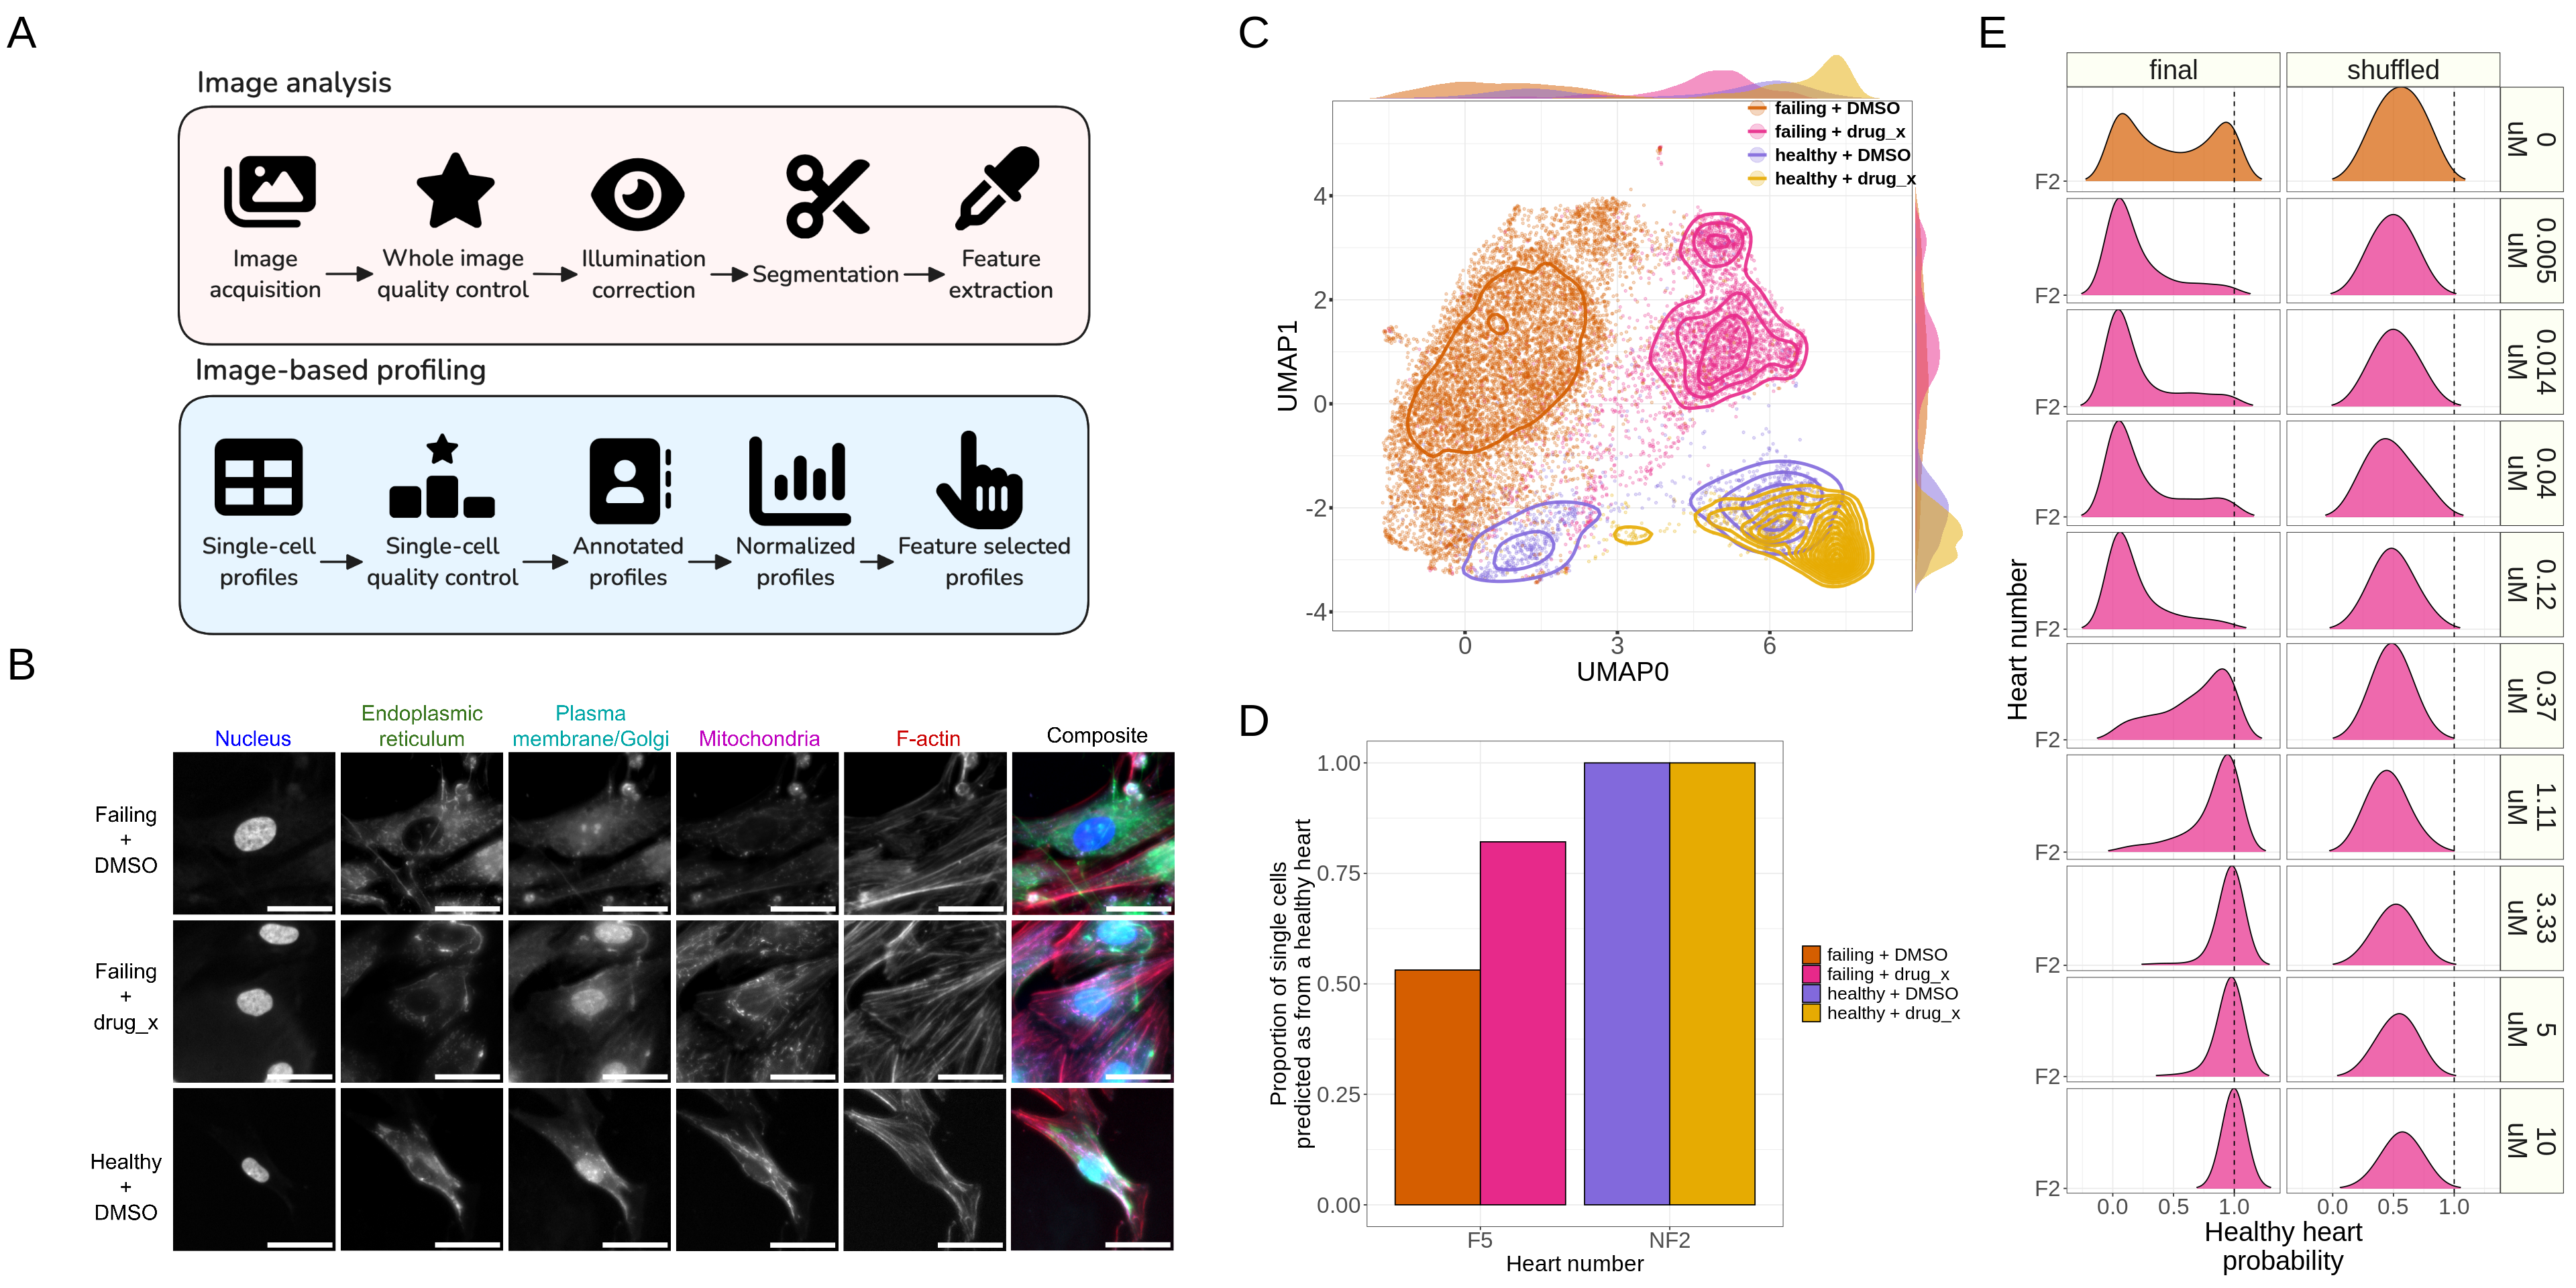

In [14]:
width <- 32
height <- 16
options(repr.plot.width = width, repr.plot.height = height)

main_figure <- (
    panels_a_b_c_d_gg |
        free(ridge_plot_healthy)
) +
    plot_layout(widths = c(2.15, 1.25, 1)) +
    plot_annotation(tag_levels = "A") & theme(plot.tag = element_text(size = 40))

# Save figure
ggsave(output_main_figure, main_figure, height = height, width = width, dpi = 500)
ggsave(sub("\\.[^.]+$", ".pdf", output_main_figure), main_figure, height = height, width = width, dpi = 500)

main_figure
